<a href="https://colab.research.google.com/github/Kabilesh006/DEEPLEARNING/blob/main/EX%203%20-%20Implementation%20of%20CNN%20for%20Image%20Classi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 3: Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Dataset used:** CIFAR-10 (10 classes of 32x32 color images) — loaded directly via `tensorflow.keras.datasets`, so no manual Kaggle download/API key is needed in Colab.

This notebook follows the lab procedure:
- Part A: Dataset preparation
- Part B: CNN model implementation
- Part C: Model training and evaluation
- Part D: Performance analysis

## Part A: Dataset Preparation

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Load the CIFAR-10 dataset (already split into train and test by Keras)
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Full training data shape:", x_train_full.shape)
print("Test data shape:", x_test.shape)

Full training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [4]:
# Preprocess: normalize pixel values to the range [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten label arrays from (N,1) to (N,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Split the training data into training and validation sets (90% train, 10% validation)
val_split = int(0.9 * len(x_train_full))
x_train, x_val = x_train_full[:val_split], x_train_full[val_split:]
y_train, y_val = y_train_full[:val_split], y_train_full[val_split:]

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


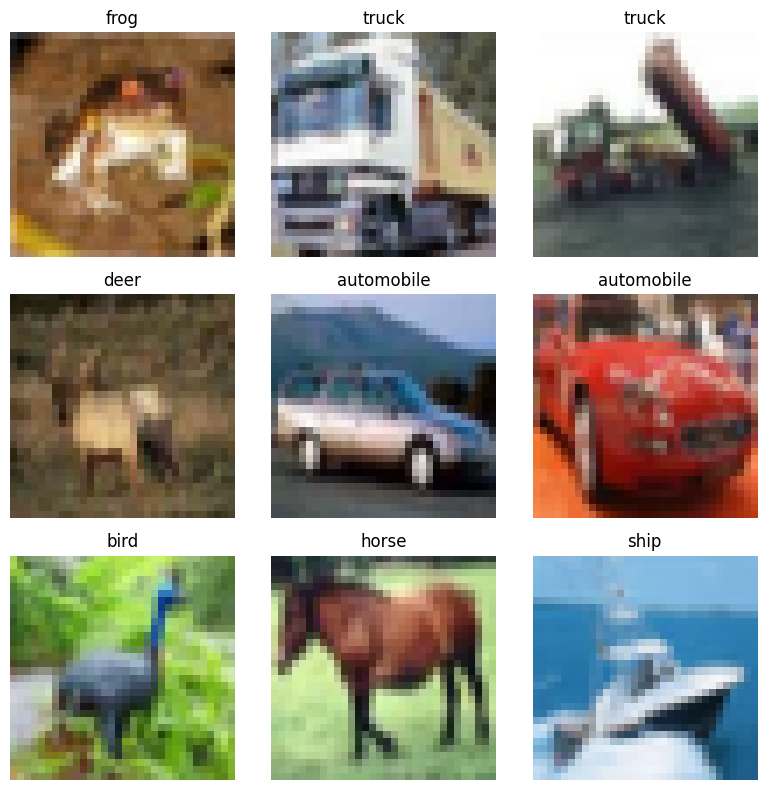

In [5]:
# Visualize a few sample images from the training set
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Part B: CNN Model Implementation

The model uses:
- Convolution layers to extract spatial features
- ReLU activation for non-linearity
- Max Pooling layers to downsample feature maps
- Fully Connected (Dense) layers to combine features
- A Softmax output layer for multi-class classification

In [6]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # Softmax output layer, 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model with the Adam optimizer and cross-entropy loss
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # labels are integers, not one-hot
    metrics=['accuracy']
)

## Part C: Model Training and Evaluation

In [8]:
EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3609 - loss: 1.7193 - val_accuracy: 0.5020 - val_loss: 1.3538
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5400 - loss: 1.2918 - val_accuracy: 0.6150 - val_loss: 1.0832
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6127 - loss: 1.0937 - val_accuracy: 0.6832 - val_loss: 0.9155
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6652 - loss: 0.9647 - val_accuracy: 0.7214 - val_loss: 0.8070
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7004 - loss: 0.8652 - val_accuracy: 0.7240 - val_loss: 0.7864
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7283 - loss: 0.7840 - val_accuracy: 0.7608 - val_loss: 0.6944
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7500 - loss: 0.7219 - val_accuracy: 0.7480 - val_loss: 0.7547
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7708 - loss: 0.6621 - val_accuracy: 

In [9]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 - 2s - 8ms/step - accuracy: 0.7638 - loss: 0.8086

Test Accuracy: 0.7638
Test Loss: 0.8086


In [10]:
# Print final training and validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Final Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Testing Accuracy          : {test_acc:.4f}")

Final Training Accuracy   : 0.8563
Final Validation Accuracy : 0.7838
Final Training Loss       : 0.4059
Final Validation Loss     : 0.7313
Testing Accuracy          : 0.7638


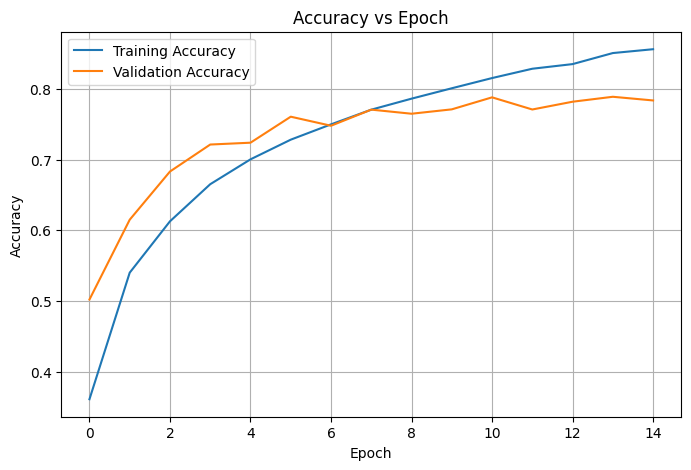

In [11]:
# Plot Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

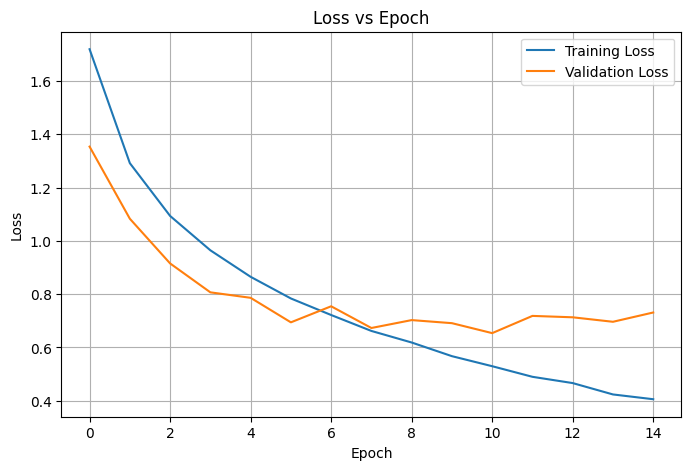

In [12]:
# Plot Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Part D: Performance Analysis

In [13]:
# Get model predictions on the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report (precision, recall, f1-score per class)
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.73      0.89      0.80      1000
  automobile       0.85      0.91      0.88      1000
        bird       0.71      0.64      0.67      1000
         cat       0.60      0.54      0.57      1000
        deer       0.76      0.67      0.71      1000
         dog       0.59      0.77      0.67      1000
        frog       0.87      0.75      0.81      1000
       horse       0.77      0.83      0.80      1000
        ship       0.93      0.82      0.87      1000
       truck       0.89      0.82      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



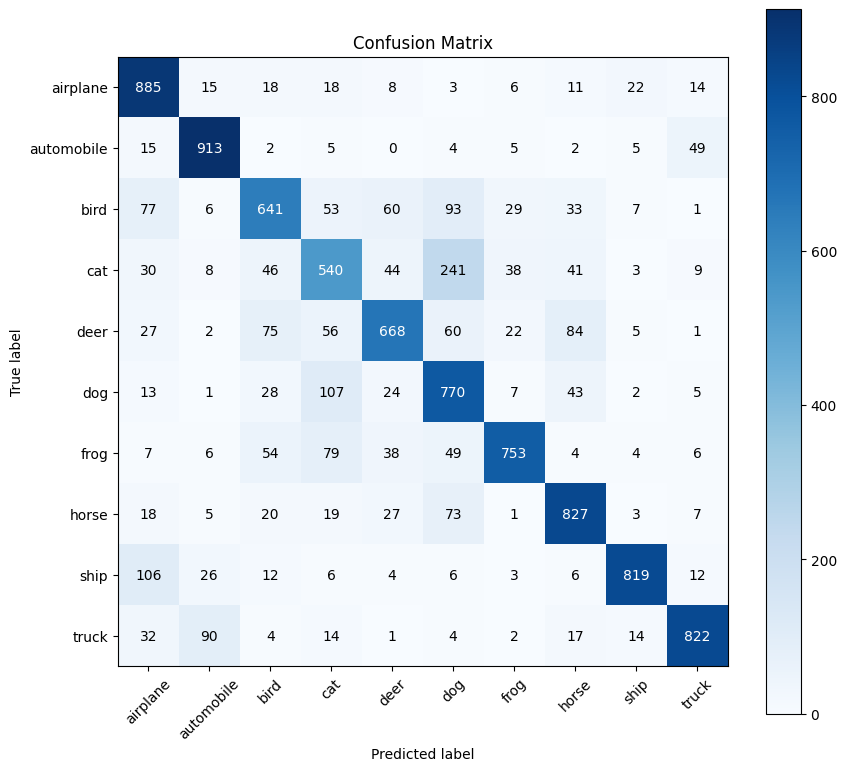

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Annotate cell counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

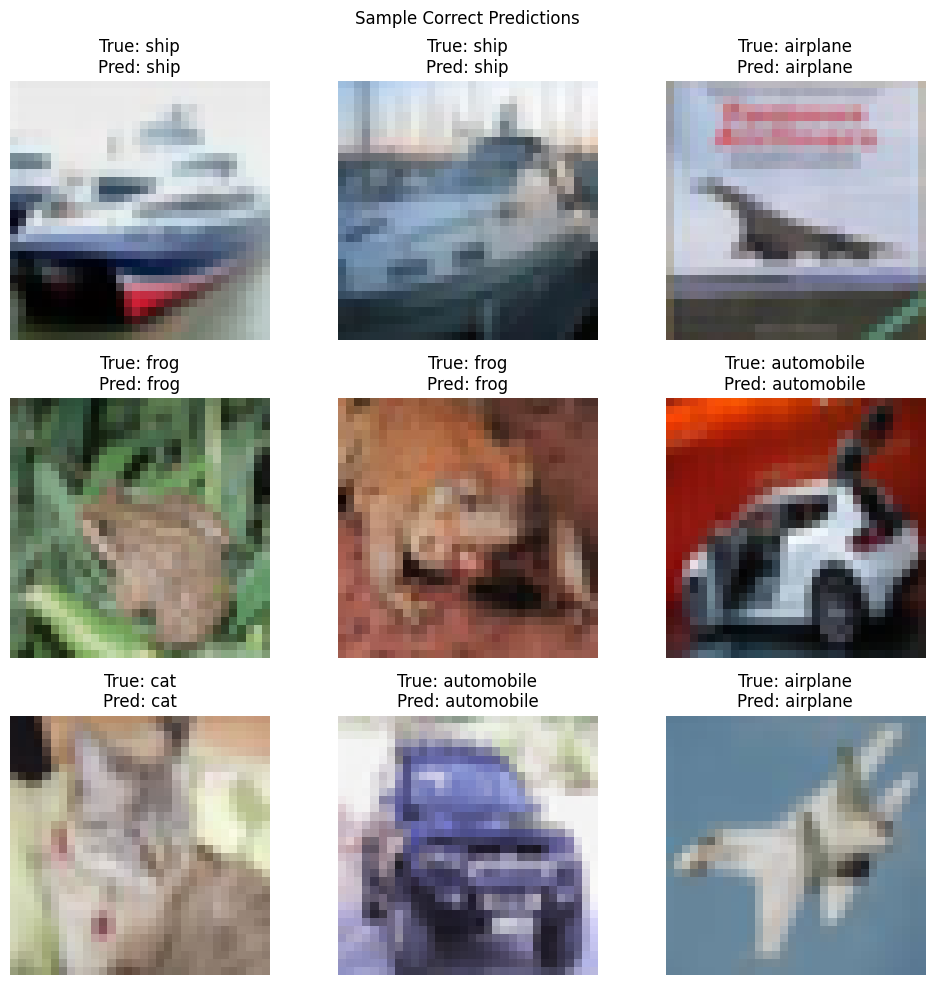

In [15]:
# Sample predictions: correctly classified images
correct_idx = np.where(y_pred == y_test)[0]

plt.figure(figsize=(10, 10))
for i, idx in enumerate(correct_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Sample Correct Predictions")
plt.tight_layout()
plt.show()

Number of misclassified test images: 2362 out of 10000


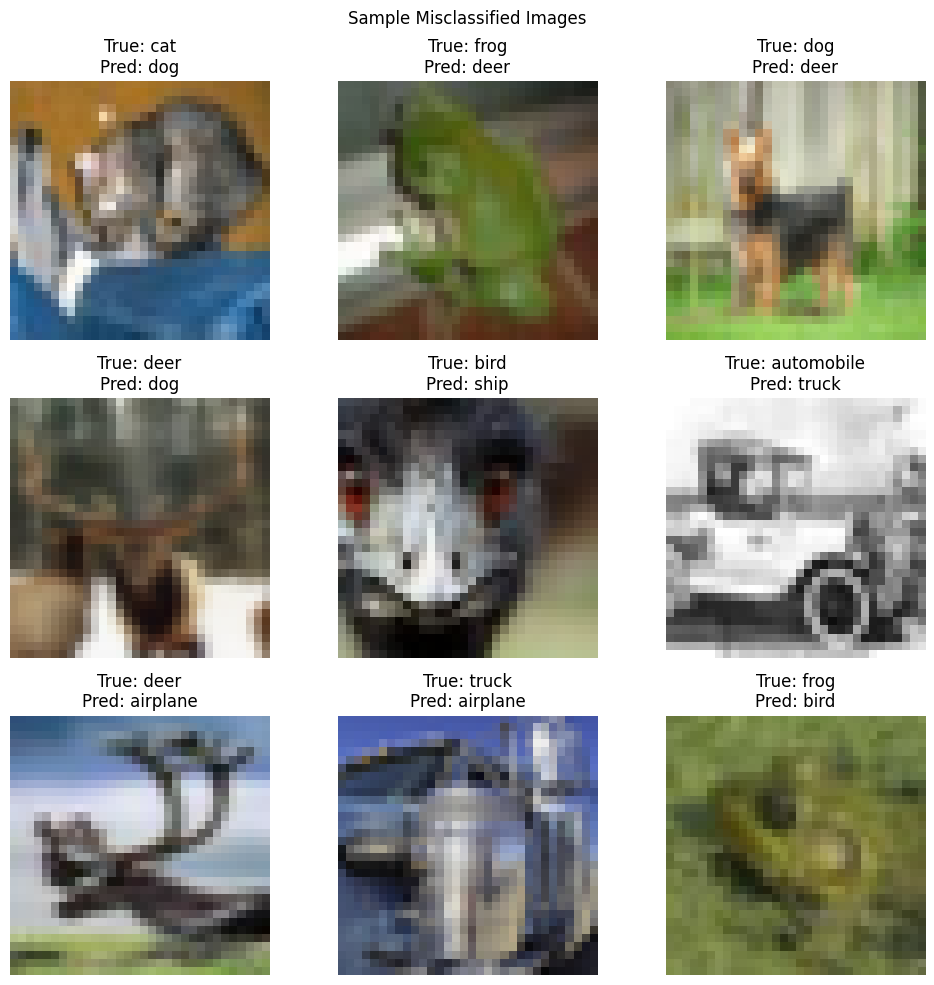

In [16]:
# Misclassified images
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_idx)} out of {len(y_test)}")

plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()

### Discussion: Strengths and Limitations of CNNs for Image Classification

**Strengths**
- Automatically learn spatial hierarchies of features (edges → textures → shapes → objects) without manual feature engineering.
- Parameter sharing in convolution layers makes CNNs far more efficient than fully connected networks for image data.
- Translation invariance from pooling layers helps the model recognize objects regardless of their position in the image.

**Limitations**
- Require large amounts of labeled data and significant computational resources (GPU) to train well.
- Performance can degrade on classes with visually similar features (e.g., cat vs dog, automobile vs truck), as seen in the confusion matrix above.
- Sensitive to hyperparameter choices (learning rate, number of filters, depth) and prone to overfitting on small datasets without regularization (dropout, data augmentation).